In [2]:
from tqdm import tqdm
from multiprocess import Pool
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from precip_ext_model import *
import cmcrameri.cm as cmc

In [3]:
## Set the plotting parameters
params={     
    'axes.labelsize'  : '8',   
    'axes.titlesize'  : '8',  
    'xtick.labelsize' :'8',
    'ytick.labelsize' :'8',    
    'lines.linewidth' : '1' ,   
    'legend.fontsize' : '8', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)

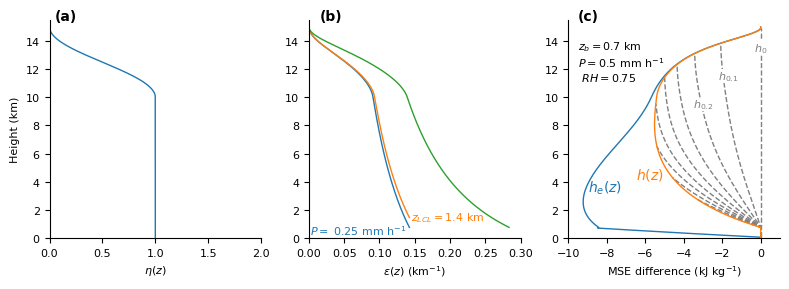

In [15]:
# Set the model parameters
z_lcl = 700
mprofile = "cos"
RH = 0.75
P = 4

df,ent_spec = spectral_plume_lcl(model_type="precip", RH=RH, P=P, z_lcl=z_lcl,get_plane=False, plotting=False, save_data=False,mprofile=mprofile)
  



fig = plt.figure(figsize=(8,3))
#plt.plot(df["T"],df.z/1000)

ax1 = fig.add_subplot(131)

plt.plot(df.M,df.z/1000,linewidth=1)


ax1.set_xlim(0,2)
ax1.set_ylim(0,15.5)
ax1.set_xlabel(r"$\eta(z)$")
ax1.set_ylabel(r"Height (km)")
ax1.text(0.05,15.5,"(a)",fontweight="bold",fontsize=10)


ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)





#########################

ax2 = fig.add_subplot(133)


h_env_sat = calc_MSE(df.T_env,df.qsat_env,df.p,df.z)

dh_env = (df.h_env-df.h[0] )/1000
dh_env_sat = (h_env_sat - df.h[0])/1000
dh = (df.h-df.h[0])/1000

for i in range(10):
   
   dh_plume = (df[f"h{i:02d}"] - df.h[0])/1000
   dh_plume[dh_plume<dh]=np.nan
   plt.plot(dh_plume,df.z/1000,'--',color="gray")   




plt.plot(dh_env,df.z/1000)
plt.plot(dh,df.z/1000)
#plt.plot(dh_env_sat,df.z/1000)

XX = 10

ax2.set_xlim(-XX,XX*0.1)
ax2.set_ylim(0,15.5)
ax2.set_xlabel(r"MSE difference (kJ kg$^{-1}$)")
#ax2.set_ylabel(r"height (km)")
ax2.text(-XX*0.95,15.5,"(c)",fontweight="bold",fontsize=10)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.text(
        -9.5, 11,
        "$z_{b} = 0.7$ km \n$P = 0.5$ mm h$^{-1}$\n $RH = 0.75$",
        color="k",
        fontsize=8,
        ha="left",
        va="bottom"
    )


colors = [line.get_color() for line in ax2.get_lines()]

plt.text(
        -9, 3,
        "$h_{e}(z)$",
        fontsize=10,
        ha="left",
        va="bottom",
        color=colors[10]
    )



plt.text(
        -6.5, 4,
        r"$h(z)$",
        fontsize=10,
        ha="left",
        va="bottom",
        color=colors[11]
    )


plt.text(
        0, 13,
        "$h_{0}$",
        fontsize=8,
        ha="center",
        va="bottom",
        color="gray",
        bbox=dict(facecolor="white", edgecolor="none", pad=0)
    )

plt.text(
        -1.7, 11,
        "$h_{0.1}$",
        fontsize=8,
        ha="center",
        va="bottom",
        color="gray",
        bbox=dict(facecolor="white", edgecolor="none", pad=0)
    )

plt.text(
        -3, 9,
        "$h_{0.2}$",
        fontsize=8,
        ha="center",
        va="bottom",
        color="gray",
        bbox=dict(facecolor="white", edgecolor="none", pad=0)
    )
#########################


# Set the model parameters
z_lcl = 700
mprofile = "cos"
RH = 0.75
P = 2
df,ent_spec = spectral_plume_lcl(model_type="precip", RH=RH, P=P, z_lcl=z_lcl,get_plane=False, plotting=False, save_data=False,mprofile=mprofile)

ax3 = fig.add_subplot(132)
z = df.z
plt.plot(df.ent[z>z_lcl]*1000,z[z>z_lcl]/1000,label="$z_{LCL}$ = 700 m")

ax3.set_xlim(0,0.3)
ax3.set_ylim(0,15.5)
ax3.set_xlabel(r"$\epsilon(z)$ (km$^{-1}$)")
#ax3.set_ylabel(r"height (km)")
ax3.text(0.015,15.5,"(b)",fontweight="bold",fontsize=10)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)


# Set the model parameters
z_lcl = 1400
mprofile = "cos"
RH = 0.75
P = 4
df,ent_spec = spectral_plume_lcl(model_type="precip", RH=RH, P=P, z_lcl=z_lcl,get_plane=False, plotting=False, save_data=False,mprofile=mprofile)
  
plt.plot(df.ent[z>z_lcl]*1000,z[z>z_lcl]/1000)

# Set the model parameters
z_lcl = 700
mprofile = "cos"
RH = 0.75
P = 4
df,ent_spec = spectral_plume_lcl(model_type="precip", RH=RH, P=P, z_lcl=z_lcl,get_plane=False, plotting=False, save_data=False,mprofile=mprofile)

plt.plot(df.ent[z>z_lcl]*1000,z[z>z_lcl]/1000)



colors = [line.get_color() for line in ax3.get_lines()]

#ax3.legend(loc="upper right", frameon=False, fontsize=8)

plt.text(
        0.145, 1,
        "$z_{LCL} = 1.4$ km",
        fontsize=8,
        ha="left",
        va="bottom",
        color=colors[1]
    )

plt.text(
        0.001, 0.1,
        "$P =$ 0.25 mm h$^{-1}$",
        color=colors[0],
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.tight_layout()
fig.savefig("Figures/Paper/Plume_spectrum_profiles.pdf")

In [136]:
 
colors = [line.get_color() for line in ax2.get_lines()]

In [137]:
colors

['gray',
 'gray',
 'gray',
 'gray',
 'gray',
 'gray',
 'gray',
 'gray',
 'gray',
 'gray',
 '#1f77b4',
 '#ff7f0e']